In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
data = load_iris()

In [28]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [29]:
cols = data['feature_names']

In [30]:
X = pd.DataFrame(data['data'],columns=cols)
y = data['target']

In [31]:
# Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [32]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()

In [33]:
dtc.fit(X_train,y_train)

DecisionTreeClassifier()

[Text(0.5555555555555556, 0.9166666666666666, 'x[2] <= 2.45\ngini = 0.665\nsamples = 120\nvalue = [37, 44, 39]'),
 Text(0.4444444444444444, 0.75, 'gini = 0.0\nsamples = 37\nvalue = [37, 0, 0]'),
 Text(0.5, 0.8333333333333333, 'True  '),
 Text(0.6666666666666666, 0.75, 'x[3] <= 1.75\ngini = 0.498\nsamples = 83\nvalue = [0, 44, 39]'),
 Text(0.6111111111111112, 0.8333333333333333, '  False'),
 Text(0.5555555555555556, 0.5833333333333334, 'x[2] <= 5.05\ngini = 0.153\nsamples = 48\nvalue = [0, 44, 4]'),
 Text(0.3333333333333333, 0.4166666666666667, 'x[0] <= 4.95\ngini = 0.044\nsamples = 44\nvalue = [0, 43, 1]'),
 Text(0.2222222222222222, 0.25, 'x[3] <= 1.35\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.1111111111111111, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.3333333333333333, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.4444444444444444, 0.25, 'gini = 0.0\nsamples = 42\nvalue = [0, 42, 0]'),
 Text(0.777777777777777

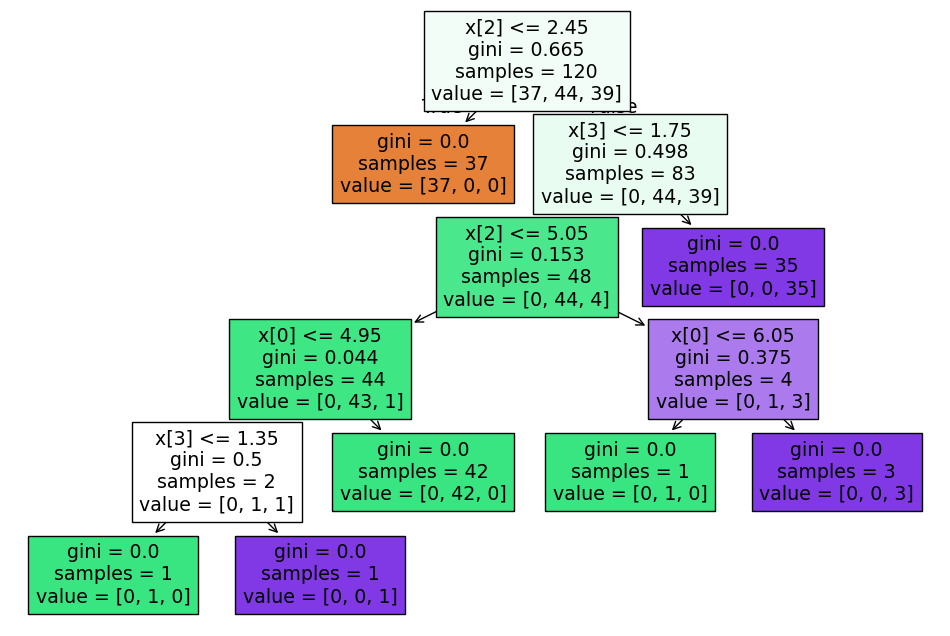

In [34]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(dtc,filled=True)

In [35]:
## Prepruning & Hyperparameter Tuning
params = {
    'criterion':['gini','entropy'],
    'max_depth':[2,3,4,5],
    'max_features':['sqrt','log2','auto']
}

In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
treemodel = DecisionTreeClassifier()

In [38]:
grid = GridSearchCV(treemodel,param_grid=params,cv=5,scoring='accuracy')

In [39]:
grid.fit(X_train,y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 436, in _validate_params

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5],
                         'max_features': ['sqrt', 'log2', 'auto']},
             scoring='accuracy')

In [40]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt'}

In [41]:
grid.best_score_

np.float64(0.9666666666666668)

In [42]:
y_pred=grid.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.83      0.83      0.83         6
           2       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.91      0.91      0.91        30
weighted avg       0.93      0.93      0.93        30

